In [1]:
# Preliminary features & parameters
import src.simulations.backtest_portfolio_v2 as bp
from src import indicators

features = {
        'sma_trend_regime': {
            'func': indicators.calculate_sma_crossover,
            'params': {'fast_window': 10, 'slow_window': 30, 'binary': True},
        },
        'sma_position_fast': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 10},
        },
        'sma_position_slow': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 30}
        },
        'rsi': {
            'func': indicators.calculate_rsi,
            'params': {'window': 14},
        },
        'bollinger_position': {
            'func': indicators.calculate_bollinger_position,
            'params': {'window': 20, 'num_std': 2},
        },
        'price_roc_fast': {
            'func': indicators.calculate_roc,
            'params': {'window': 1}
        },
        'price_roc_slow': {
            'func': indicators.calculate_roc,
            'params': {'window': 5}
        },
    }

# Use QQQ
ticker_pool_tech = [
        "NVDA", "MSFT", "AVGO", "NOW",
        "ORCL", "AAPL", "TEAM", "INTC",
        "SNOW", "WIX",  "AMD",  "CSCO",
        "SHOP", "AMZN", "CRM",
    ]

# Use SPY
ticker_pool_general = [
    "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL",
    "UNH", "LLY", "JNJ",
    "XOM", "CVX",
    "JPM", "BRK-B",
    "WMT", "PG",
    "GLD"
]

ticker_pool = ticker_pool_general
 
benchmark = "SPY"

/Users/jasonshi/Desktop/Python/finance_project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Functionize model testing & plotting
import src.stock_screener as sc
import matplotlib.pyplot as plt
import seaborn as sns

def run_with_model(input_model, features_dict):
    engine = bp.PortfolioBacktestEngine(
        model=input_model,
        feature_configs=features_dict,
        confidence_threshold=0.60,
        bear_confidence_threshold=0.75,
        stop_loss=0.10,
        min_hold_days=7,
        adx_threshold=20,
        training_years=5,
        testing_years=5,
        offset_years=0
    )

    total_years = engine.training_years + engine.testing_years + engine.offset_years
    print(f"Downloading {total_years}y of data for {len(ticker_pool)} tickers + {benchmark}...")
    master_df = sc.fetch_screener_data(
        ticker_pool + [benchmark], period=f"{total_years}y", interval="1d"
    )
    print("Download Complete.")

    benchmark_prices = master_df['Close'][benchmark]
    benchmark_prices.name = benchmark

    engine.run_simulation(
        ticker_pool=ticker_pool,
        pre_downloaded_df=master_df,
        benchmark_prices=benchmark_prices,
    )

    print("\nTrade Log:")
    print(engine.last_trade_log.to_string(index=False))
    return engine, benchmark_prices

def plot_results(engine, benchmark_prices):
    sns.set_theme(style='darkgrid')
    bench = benchmark_prices.loc[engine.last_equity_curve.index]
    bench = bench / bench.iloc[0] * 10_000

    plt.figure(figsize=(12, 5))
    plt.plot(engine.last_equity_curve, label='Strategy', color='#2ecc71', linewidth=2)
    plt.plot(bench, label='Benchmark', color='#3498db', linewidth=2, linestyle='--')
    plt.title(f"Strategy {engine.last_strategy_return:+.2f}% | {benchmark} {engine.last_benchmark_return:+.2f}% | Alpha {engine.last_alpha:+.2f}%", fontsize=13)
    plt.ylabel('Portfolio Value')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching historical data for companies: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'GOOGL', 'UNH', 'LLY', 'JNJ', 'XOM', 'CVX', 'JPM', 'BRK-B', 'WMT', 'PG', 'GLD', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2016-06-27 to 2021-06-24
  Test window  : 2021-06-24 to 2026-06-24
  Strategy Return   : +257.14%
  Benchmark (SPY) : +77.59%
  Alpha             : +179.55%
  Win Rate          : 55.78%
  Total Trades      : 147

Trade Log:
     type ticker       price       date     return
      BUY   AMZN  168.799500 2021-08-05        NaN
     SELL   AMZN  164.949493 2021-08-16  -2.280816
      BUY    XOM   47.250359 2021-08-16        NaN
     SELL    XOM   46.844917 2021-08-25  -0.858070
      BUY    LLY  250.082230 2021-08-26        NaN
STOP_LOSS    LLY  223.066223 2021-09-14 -10.802849
      BUY    LLY  223.066223 2021-09-14        NaN
     SELL    LLY  222.195343 2021-09-23  -0.390413
      BUY    UNH  375.070038 2021-09-23        NaN
     SELL    UNH  355.747986 2021-10-04  -5.151585
      BUY   NVDA   19.667454 2021-10-04        NaN
     SELL   NVDA   20.870502 2021-10-13   6.116952
      BUY    JPM  143.567368 2021-10-13        

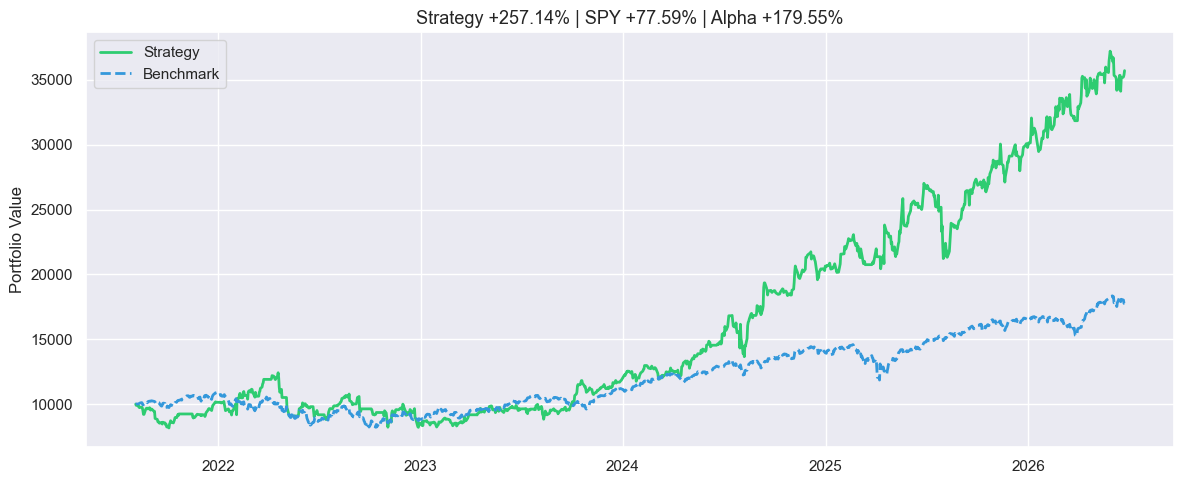

In [3]:
from sklearn import ensemble
rf_classifier = ensemble.RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        min_samples_split=10,
        max_features='sqrt',
        max_depth=10
    )
engine, benchmark_prices = run_with_model(input_model=rf_classifier, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'GOOGL', 'UNH', 'LLY', 'JNJ', 'XOM', 'CVX', 'JPM', 'BRK-B', 'WMT', 'PG', 'GLD', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2016-06-27 to 2021-06-24
  Test window  : 2021-06-24 to 2026-06-24
  Strategy Return   : +337.07%
  Benchmark (SPY) : +77.59%
  Alpha             : +259.48%
  Win Rate          : 55.03%
  Total Trades      : 149

Trade Log:
     type ticker       price       date     return
      BUY   AMZN  168.799500 2021-08-05        NaN
     SELL   AMZN  164.949493 2021-08-16  -2.280816
      BUY    XOM   47.250351 2021-08-16        NaN
     SELL    XOM   46.844921 2021-08-25  -0.858046
      BUY    LLY  250.082199 2021-08-26        NaN
STOP_LOSS    LLY  223.066223 2021-09-14 -10.802838
      BUY    LLY  223.066223 2021-09-14        NaN
     SELL    LLY  222.195328 2021-09-23  -0.390420
      BUY    UNH  375.069977 2021-09-23        NaN
     SELL    UNH  355.747955 2021-10-04  -5.151578
      BUY   MSFT  272.219849 2021-10-04        NaN
     SELL   MSFT  284.912170 2021-10-13   4.662526
      BUY    JPM  143.567352 2021-10-13        

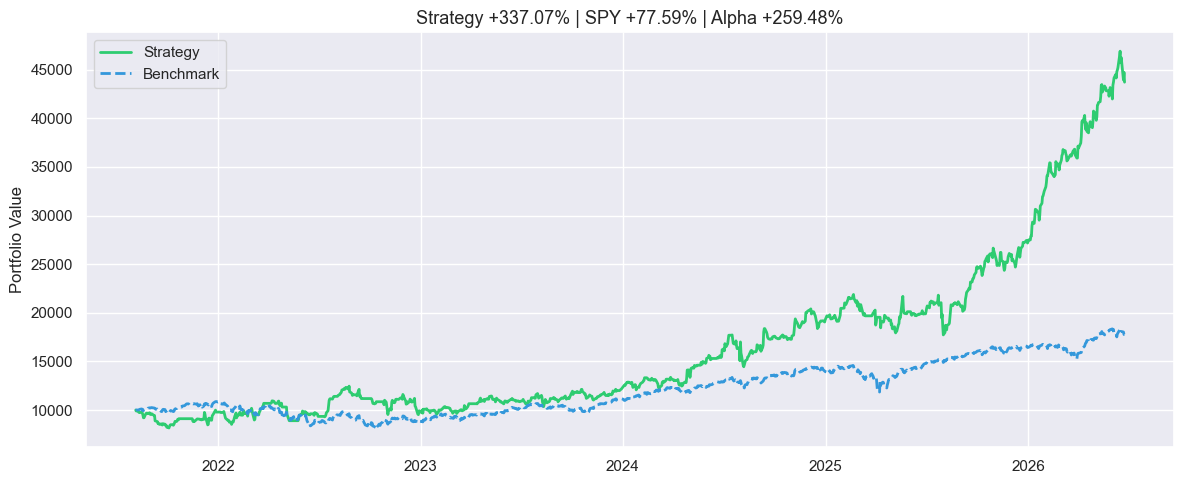

In [4]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05)

engine, benchmark_prices = run_with_model(input_model=xgb_model, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'GOOGL', 'UNH', 'LLY', 'JNJ', 'XOM', 'CVX', 'JPM', 'BRK-B', 'WMT', 'PG', 'GLD', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2016-06-27 to 2021-06-24
  Test window  : 2021-06-24 to 2026-06-24
  Strategy Return   : +123.10%
  Benchmark (SPY) : +77.59%
  Alpha             : +45.50%
  Win Rate          : 52.03%
  Total Trades      : 148

Trade Log:
     type ticker       price       date     return
      BUY   AMZN  168.799500 2021-08-05        NaN
     SELL   AMZN  164.949493 2021-08-16  -2.280816
      BUY    XOM   47.250347 2021-08-16        NaN
     SELL    XOM   46.844917 2021-08-25  -0.858046
      BUY    JNJ  151.458389 2021-08-26        NaN
     SELL    JNJ  150.601929 2021-09-07  -0.565476
      BUY    LLY  243.842606 2021-09-07        NaN
     SELL    LLY  221.678543 2021-09-20  -9.089495
      BUY   NVDA   21.043940 2021-09-20        NaN
     SELL   NVDA   20.449883 2021-09-29  -2.822937
      BUY  GOOGL  133.172638 2021-09-29        NaN
     SELL  GOOGL  138.556885 2021-10-08   4.043058
      BUY   AMZN  162.315002 2021-10-11        N

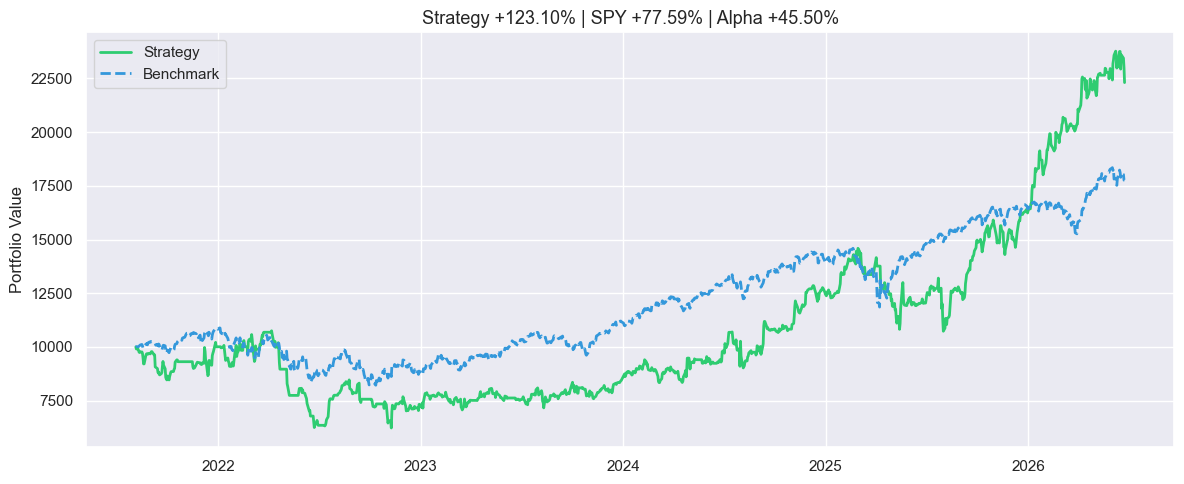

In [5]:
from sklearn.linear_model import LogisticRegression

# There was some noise based on dividing by 0, etc. that we filter out
import warnings
warnings.filterwarnings('ignore')

logreg_model = LogisticRegression(C=0.1)

engine, benchmark_prices = run_with_model(input_model=logreg_model, features_dict=features)
plot_results(engine, benchmark_prices)